In [1]:
# Enable automatic reloading of imported modules when their source changes
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from waxa import atomdata
from waxa.plotting import *

In [297]:
# ad = atomdata(62825,'andor_all')
ad = atomdata(65020,'andor_all')

65020
[atomdata timing] load total=6.471s | get_data_file(initial)=3.412s | h5_open=0.011s | headers=0.033s | core_arrays=0.469s | datavault=0.001s | scope_data=2.541s
No ROI saved in run 65020 (cached).
ROI specified by string. Referencing roi.xslx spreadsheet (PotassiumData)...
ROI andor_all found.
[atomdata timing] init total=13.551s | load_data=6.471s | setup+roi=0.002s | unshuffle_old=0.000s | initial_analysis=7.078s


In [276]:
print(ad.params.amp_imaging)

0.47241379310344833


65020


Text(0.5, 1.0, 'Run 65020')

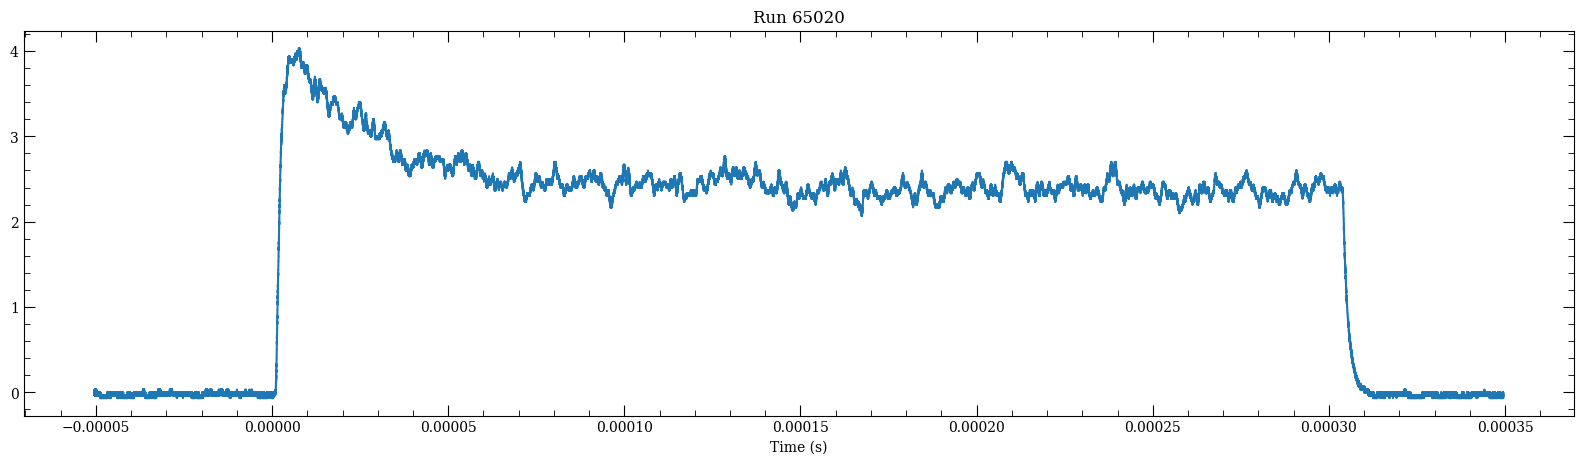

In [298]:
trace = ad.scope_data['PD'][0]

cuton = 0
cutoff = 800000

fig, axes = plt.subplots(1, figsize=[20,5])

print(ad.run_info.run_id)
idx = 2
axes.plot(trace.t[idx][cuton:cutoff],trace.v[idx][cuton:cutoff])
axes.set_xlabel('Time (s)')
plt.title(f'Run {ad.run_info.run_id}')

In [248]:
print(np.std(trace.v[idx][cuton:cutoff]))

1.1631068


In [299]:
# Average repeats together into new array (works only for 1d xvar scan)

print(np.shape(trace.v)[0]/ad.params.N_repeats)

averaged_traces = np.zeros((int(np.shape(trace.v)[0]/ad.params.N_repeats),np.shape(trace.v)[1]))

for n in range(0,np.shape(trace.v)[0],ad.params.N_repeats):
    sum_trace = np.zeros((np.shape(trace.v)[1]))
    for t in range(ad.params.N_repeats):
        t = t + n
        sum_trace = trace.v[t] + sum_trace
    averaged_traces[int(n/ad.params.N_repeats)] = sum_trace / ad.params.N_repeats

13.0


65020


Text(0.5, 1.0, 'Run 65020')

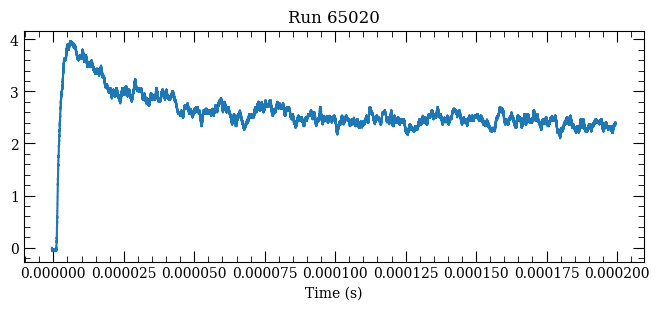

In [300]:
cuton = 100000
cutoff = 500000

fig, axes = plt.subplots(1, figsize=[8,3])

print(ad.run_info.run_id)
idx = 0
axes.plot(trace.t[idx][cuton:cutoff],trace.v[idx][cuton:cutoff])
# axes.set_ylim(0.,4.5)
# axes.set_xlim(0.,30.e-6)
axes.set_xlabel('Time (s)')
plt.title(f'Run {ad.run_info.run_id}')

In [301]:
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_traces_grid(averaged_traces, x, labels=None, ncols=None, figsize=(12,8),
                     decimate=None, sharex=True, sharey=False, suptitle=None, xlabel=None,
                     ylim = None, xlim = None):
    """
    Plot each row of averaged_traces as a subplot in a grid.

    averaged_traces: (N, M) array where N=number of traces (20), M=points
    x: 1D x axis array with length M (e.g., trace.t[0])
    labels: list/array of length N with subplot labels (can be None)
    ncols: number of columns in grid (auto if None)
    figsize: figure size
    decimate: int or None — if int>1, plot every decimate-th sample to speed up
    sharex/sharey: whether to share axes
    suptitle: optional overall title
    """
    N = averaged_traces.shape[0]
    if labels is None:
        labels = [f"Trace {i}" for i in range(N)]
    if ncols is None:
        ncols = int(math.ceil(math.sqrt(N)))
    nrows = int(math.ceil(N / ncols))

    if decimate is not None and decimate > 1:
        x = x[::decimate]
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=sharex, sharey=sharey)
    axes = np.array(axes).reshape(-1)  # flatten to 1D for easy indexing

    for i in range(nrows * ncols):
        ax = axes[i]
        if i < N:
            trace = averaged_traces[i]
            if decimate is not None and decimate > 1:
                trace = trace[::decimate]
            ax.plot(x, trace, lw=0.8)
            ax.set_title(labels[i], fontsize=10)
            ax.grid(True, alpha=0.3)
            if ylim is not None:
                ax.set_ylim(ylim[0],ylim[1])
            if xlim is not None:
                ax.set_xlim(xlim[0],xlim[1])
        else:
            ax.axis('off')  # turn off unused subplots

    if suptitle:
        fig.suptitle(suptitle)
    # single x-label (prefer supxlabel when available)
    if xlabel is not None:
        if hasattr(fig, "supxlabel"):
            fig.supxlabel(xlabel)
        else:
            fig.text(0.5, 0.02, xlabel, ha='center', fontsize=11)

    # leave room for labels/title
    fig.tight_layout(rect=[0.03, 0.01, 1, 0.99])
    plt.show()
    return fig, axes[:N]



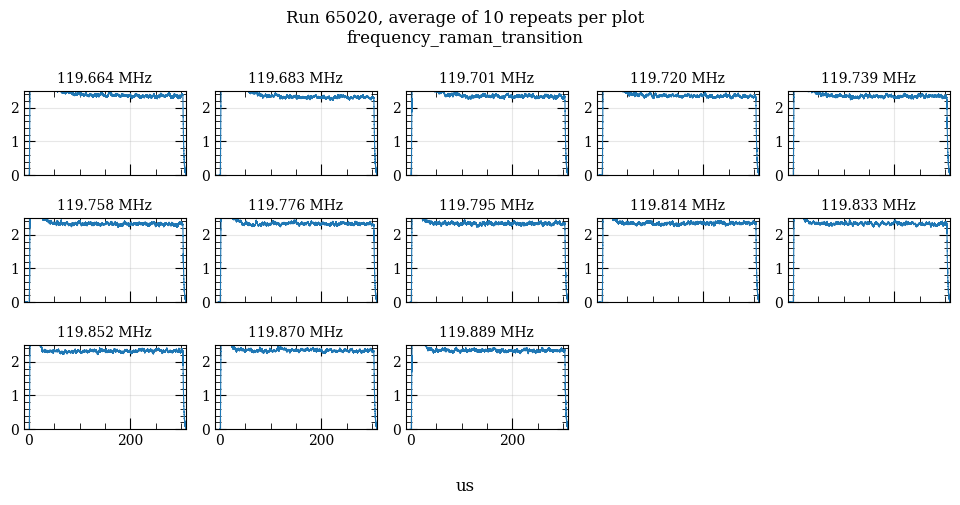

In [302]:
# Example usage:
# averaged_traces is (20, 200000), trace.t[0] is length 200000

xvarunit, xvarmult, xvarname = detect_unit(ad, 0, xvarunit="", xvarmult=1.)
labels = [f"{ad.xvars[0][i * ad.params.N_repeats]*xvarmult:.3f} {xvarunit}" for i in range(int(ad.xvardims[0]/ad.p.N_repeats))]
fig, axes = plot_traces_grid(averaged_traces, trace.t[0]*1.e6, labels=labels, ncols=5, decimate=None, figsize=(10,5),
                             suptitle=f'Run {ad.run_info.run_id}, average of {ad.params.N_repeats} repeats per plot\n' +
                             f'{ad.xvarnames[0]}',
                             xlabel='us',
                             ylim=[.0,2.5],xlim=[-10.,310])

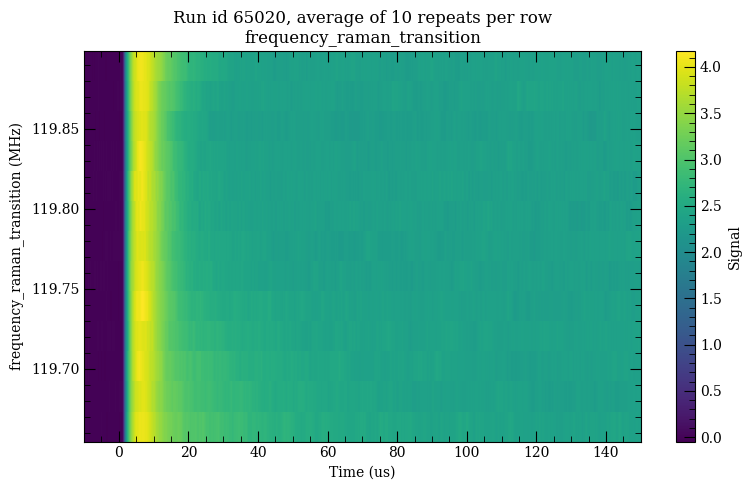

In [303]:

t_us = trace.t[0] * 1e6

# x variable info
xvarunit, xvarmult, xvarname = detect_unit(ad, 0, xvarunit="", xvarmult=1.)

xvals = np.array([
    ad.xvars[0][i * ad.params.N_repeats] * xvarmult
    for i in range(int(ad.xvardims[0] / ad.params.N_repeats))
])

ncurves = min(len(averaged_traces), len(xvals))
Z = np.asarray(averaged_traces[:ncurves])
xvals = xvals[:ncurves]

tmin = -10
tmax = 150
mask_t = (t_us >= tmin) & (t_us <= tmax)

t_plot = t_us[mask_t]
Z_plot = Z[:, mask_t]

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.pcolormesh(
    t_plot,
    xvals,
    Z_plot,
    shading="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Signal")

ax.set_xlabel("Time (us)")
ax.set_ylabel(f"{xvarname} ({xvarunit})" if xvarunit else xvarname)

ax.set_title(
    f"Run id {ad.run_info.run_id}, average of {ad.params.N_repeats} repeats per row\n"
    f"{ad.xvarnames[0]}"
)

plt.tight_layout()
plt.show()

### try other model

## valid

In [254]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

def H(x):
    return (x >= 0).astype(float)

def model_heaviside_decay_sine(t, A, alpha, B, beta, omega, phi, C, delta):
    return H(t - delta) * (
        A * np.exp(-alpha * t)
        + B * np.exp(-beta * t) * np.sin(omega * t + phi)
        + C
    )

def fit_single_heaviside_decay_sine(
    t, y,
    tmin=-10,
    tmax=300,
    omega_min=0.05,
    omega_max=2.0,
    alpha_min=0.0,
    alpha_max=1.0,
    beta_min=0.0,
    beta_max=1.0,
    delta_min=-20,
    delta_max=50
):
    t = np.asarray(t, float)
    y = np.asarray(y, float)

    mask = (t >= tmin) & (t <= tmax)
    t_fit = t[mask]
    y_fit = y[mask]

    if len(t_fit) < 20:
        raise RuntimeError("Not enough fitting points.")

    C0 = np.median(y_fit[-max(10, len(y_fit)//10):])
    A0 = y_fit[0] - C0
    B0 = 0.25 * (np.max(y_fit) - np.min(y_fit))

    alpha0 = 1 / 80.0
    beta0 = 1 / 80.0
    omega0 = 2 * np.pi / 20.0
    phi0 = 0.0

    y_base = np.median(y_fit[:max(10, len(y_fit)//20)])
    y_max = np.max(y_fit)
    threshold = y_base + 0.1 * (y_max - y_base)
    idx = np.where(y_fit > threshold)[0]
    delta0 = t_fit[idx[0]] if len(idx) > 0 else 0.0

    omega0 = np.clip(omega0, omega_min + 1e-9, omega_max - 1e-9)
    alpha0 = np.clip(alpha0, alpha_min + 1e-9, alpha_max - 1e-9)
    beta0 = np.clip(beta0, beta_min + 1e-9, beta_max - 1e-9)
    delta0 = np.clip(delta0, delta_min + 1e-9, delta_max - 1e-9)

    p0 = [A0, alpha0, B0, beta0, omega0, phi0, C0, delta0]

    bounds = (
        [-np.inf, alpha_min, -np.inf, beta_min, omega_min, -2*np.pi, -np.inf, delta_min],
        [ np.inf, alpha_max,  np.inf, beta_max, omega_max,  2*np.pi,  np.inf, delta_max]
    )

    popt, pcov = curve_fit(
        model_heaviside_decay_sine,
        t_fit,
        y_fit,
        p0=p0,
        bounds=bounds,
        maxfev=300000
    )

    perr = np.sqrt(np.diag(pcov))

    return popt, pcov, perr, t_fit, y_fit

In [255]:
import time

fit_results_heaviside = []
rows = []

decimate_fit = 20   # try 10, 20, 50. Larger = faster but less precise
start_all = time.time()
averaged_traces_use = np.asarray(averaged_traces[:ncurves])
labels_use = labels[:ncurves]
xvals_use = xvals[:ncurves]
for i, y in enumerate(averaged_traces_use):
    t0_loop = time.time()
    print(f"[{i+1}/{ncurves}] fitting {labels_use[i]} ...", flush=True)

    try:
        popt, pcov, perr, t_fit, y_fit = fit_single_heaviside_decay_sine(
            t_us[::decimate_fit],
            y[::decimate_fit],
            tmin=-10,
            tmax=300,
            omega_min=0.05,
            omega_max=2.0,
            alpha_min=0.0,
            alpha_max=1.0,
            beta_min=0.0,
            beta_max=1.0,
            delta_min=-20,
            delta_max=50
        )

        A, alpha, B, beta, omega, phi, C, delta = popt
        A_err, alpha_err, B_err, beta_err, omega_err, phi_err, C_err, delta_err = perr

        fit_results_heaviside.append({
            "success": True,
            "popt": popt,
            "pcov": pcov,
            "perr": perr
        })

        rows.append({
            "index": i,
            "label": labels_use[i],
            "xval": xvals_use[i],
            "A": A,
            "alpha": alpha,
            "B": B,
            "beta": beta,
            "omega": omega,
            "phi": phi,
            "C": C,
            "delta": delta,
            "A_err": A_err,
            "alpha_err": alpha_err,
            "B_err": B_err,
            "beta_err": beta_err,
            "omega_err": omega_err,
            "phi_err": phi_err,
            "C_err": C_err,
            "delta_err": delta_err,
            "f_MHz": omega / (2*np.pi),
            "f_MHz_err": omega_err / (2*np.pi),
            "success": True
        })

        print(
            f"    done in {time.time()-t0_loop:.1f}s | "
            f"omega={omega:.4f}, delta={delta:.2f}",
            flush=True
        )

    except Exception as e:
        fit_results_heaviside.append({
            "success": False,
            "popt": None,
            "pcov": None,
            "perr": None,
            "error": str(e)
        })

        rows.append({
            "index": i,
            "label": labels_use[i],
            "xval": xvals_use[i],
            "A": np.nan,
            "alpha": np.nan,
            "B": np.nan,
            "beta": np.nan,
            "omega": np.nan,
            "phi": np.nan,
            "C": np.nan,
            "delta": np.nan,
            "A_err": np.nan,
            "alpha_err": np.nan,
            "B_err": np.nan,
            "beta_err": np.nan,
            "omega_err": np.nan,
            "phi_err": np.nan,
            "C_err": np.nan,
            "delta_err": np.nan,
            "f_MHz": np.nan,
            "f_MHz_err": np.nan,
            "success": False,
            "error": str(e)
        })

        print(f"    FAILED in {time.time()-t0_loop:.1f}s: {e}", flush=True)

df_heaviside = pd.DataFrame(rows)

print(f"\nAll done in {(time.time()-start_all)/60:.1f} min")
print(df_heaviside)

[1/13] fitting 119.676 MHz ...
    done in 0.6s | omega=0.0500, delta=1.34
[2/13] fitting 119.694 MHz ...
    done in 0.4s | omega=0.0566, delta=1.33
[3/13] fitting 119.713 MHz ...
    done in 0.3s | omega=0.0968, delta=1.32
[4/13] fitting 119.732 MHz ...
    done in 0.4s | omega=0.0500, delta=1.33
[5/13] fitting 119.751 MHz ...
    done in 0.6s | omega=0.0500, delta=1.31
[6/13] fitting 119.769 MHz ...
    done in 0.4s | omega=0.0500, delta=1.33
[7/13] fitting 119.788 MHz ...
    done in 0.2s | omega=0.1327, delta=1.33
[8/13] fitting 119.807 MHz ...
    done in 0.5s | omega=0.0500, delta=1.34
[9/13] fitting 119.826 MHz ...
    done in 0.4s | omega=0.0500, delta=1.33
[10/13] fitting 119.845 MHz ...
    done in 0.7s | omega=0.0500, delta=1.33
[11/13] fitting 119.863 MHz ...
    done in 0.5s | omega=0.0500, delta=1.33
[12/13] fitting 119.882 MHz ...
    done in 0.4s | omega=0.0500, delta=1.32
[13/13] fitting 119.901 MHz ...
    done in 0.3s | omega=0.0500, delta=1.32

All done in 0.1 min


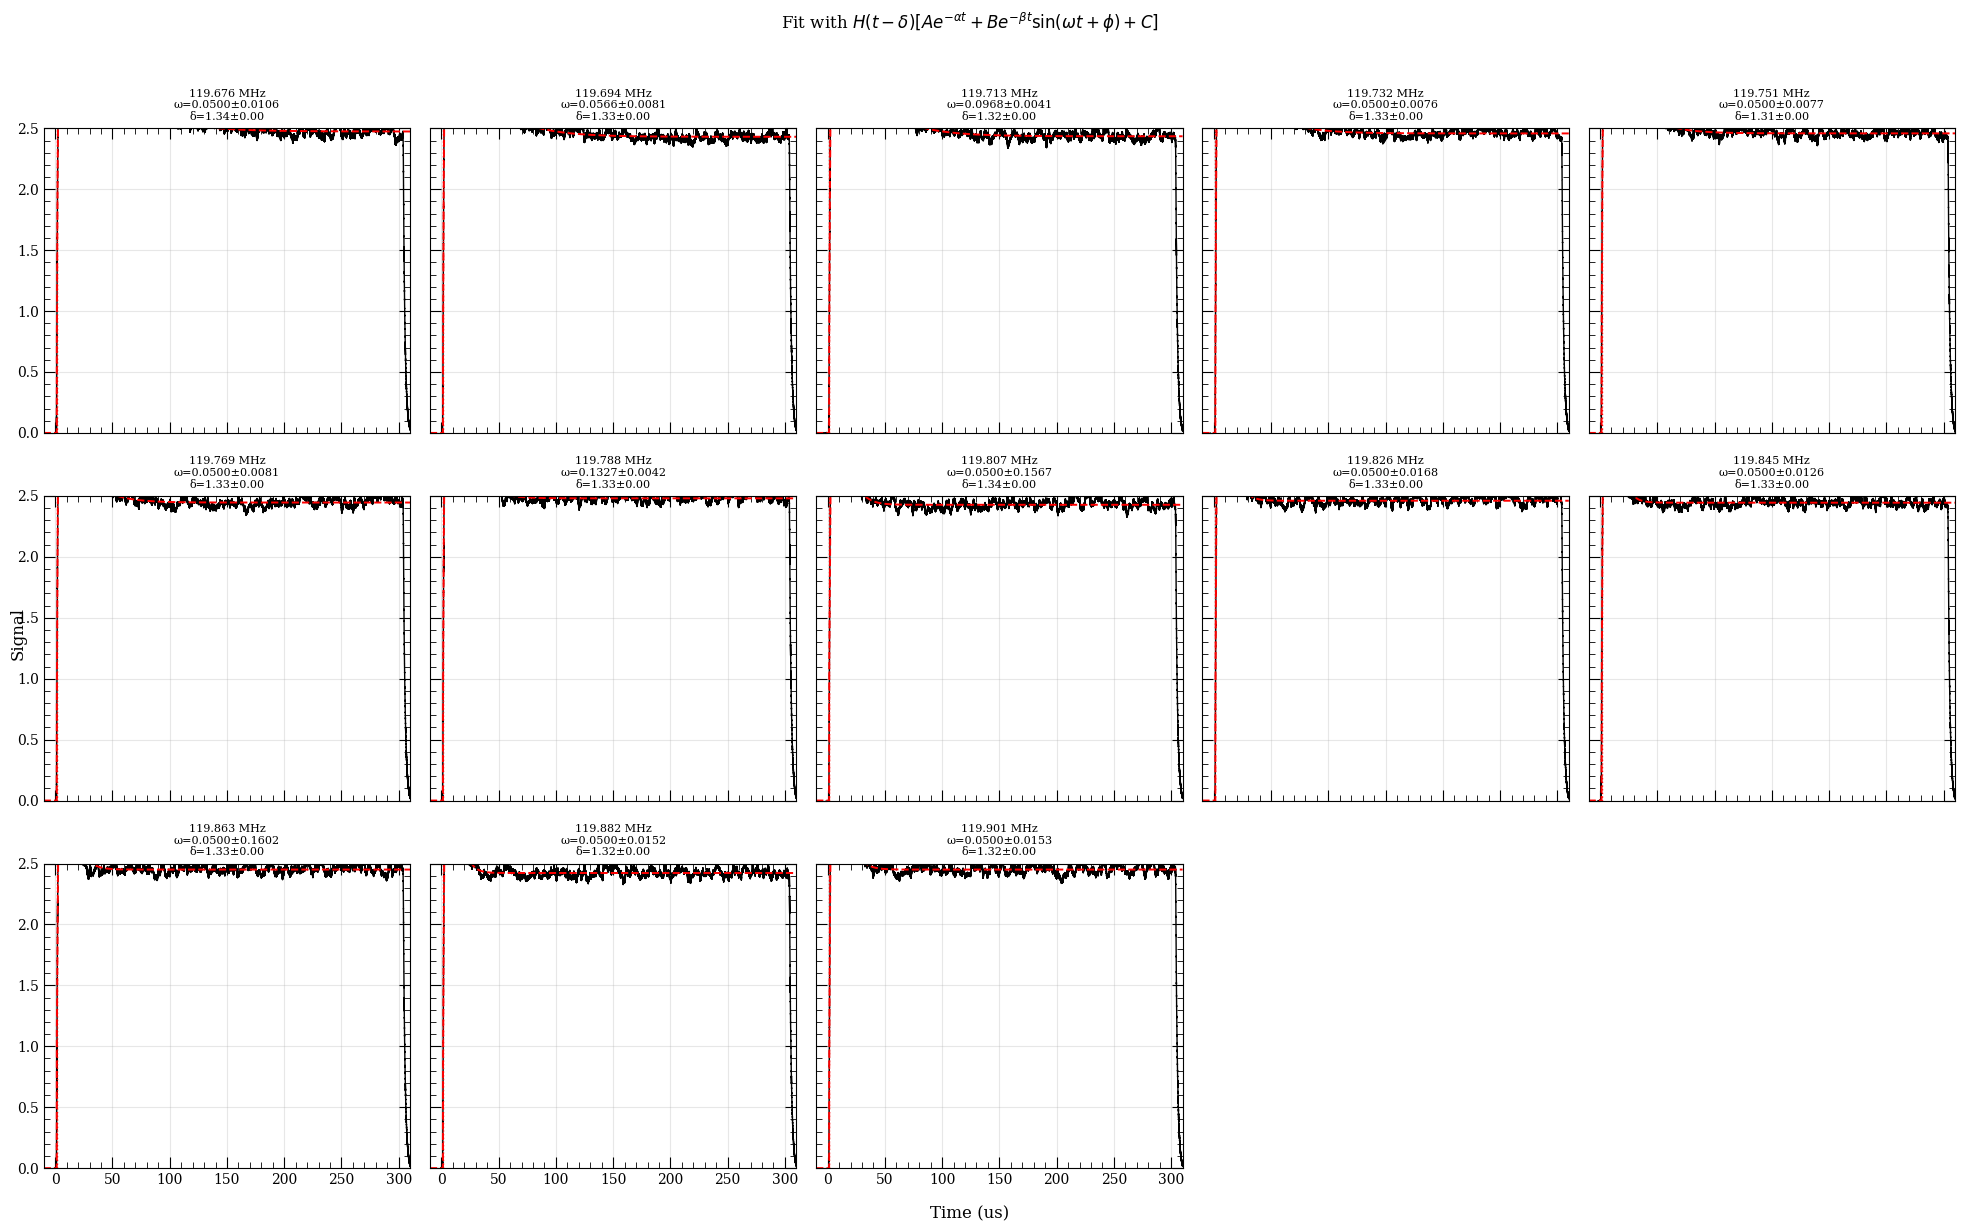

In [256]:
ncols = 5
nrows = int(np.ceil(ncurves / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 12), sharex=True, sharey=True)
axes = np.ravel(axes)

for i, y in enumerate(averaged_traces_use):
    ax = axes[i]
    res = fit_results_heaviside[i]

    ax.plot(t_us, y, color="k", lw=1.0)

    if res["success"]:
        popt = res["popt"]
        perr = res["perr"]

        y_model = model_heaviside_decay_sine(t_us, *popt)
        ax.plot(t_us, y_model, "--", color="r", lw=1.4)

        A, alpha, B, beta, omega, phi, C, delta = popt
        A_err, alpha_err, B_err, beta_err, omega_err, phi_err, C_err, delta_err = perr

        ax.axvline(delta, color="r", ls=":", lw=1)

        ax.set_title(
            f"{labels_use[i]}\n"
            f"ω={omega:.4f}±{omega_err:.4f}\n"
            f"δ={delta:.2f}±{delta_err:.2f}",
            fontsize=8
        )
    else:
        ax.set_title(f"{labels_use[i]}\nfit failed", fontsize=8)

    ax.set_xlim(-10, 310)
    ax.set_ylim(0, 2.5)
    ax.grid(alpha=0.3)

for j in range(ncurves, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    r"Fit with $H(t-\delta)[Ae^{-\alpha t}+Be^{-\beta t}\sin(\omega t+\phi)+C]$",
    y=1.02
)
fig.supxlabel("Time (us)")
fig.supylabel("Signal")

plt.tight_layout()
plt.show()

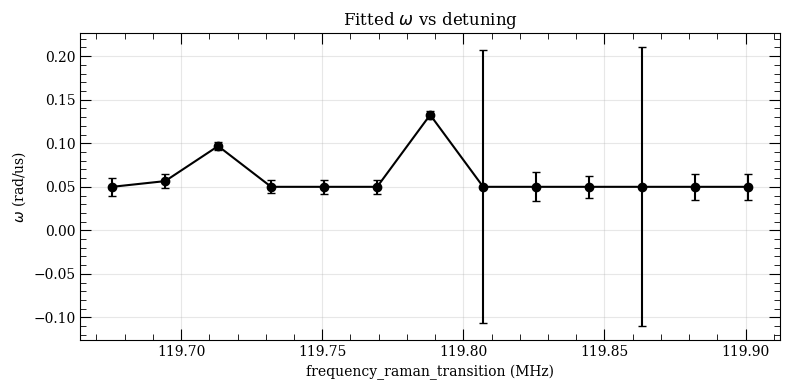

In [257]:
mask = df_heaviside["success"] & np.isfinite(df_heaviside["omega"])

fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(
    df_heaviside.loc[mask, "xval"],
    df_heaviside.loc[mask, "omega"],
    yerr=df_heaviside.loc[mask, "omega_err"],
    fmt="o-",
    color="k",
    capsize=3
)

ax.set_xlabel(f"{xvarname} ({xvarunit})" if xvarunit else xvarname)
ax.set_ylabel(r"$\omega$ (rad/us)")
ax.set_title(r"Fitted $\omega$ vs detuning")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## test

In [304]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import time

def H(x):
    return (np.asarray(x) >= 0).astype(float)

def safe_rel_err(err, val):
    if val is None or err is None:
        return np.nan
    if not np.isfinite(err) or not np.isfinite(val) or abs(val) < 1e-12:
        return np.inf
    return abs(err / val)

def mse_relative(y_fit, y_curve):
    mse = np.mean((y_curve - y_fit)**2)
    scale = np.mean(y_fit**2)
    if scale < 1e-12:
        return np.inf
    return mse / scale

# model 1
def model_osc_sq(t, A, alpha, Omega, phi, C1, C2, delta):
    T = t 
    return H(T- delta) *(      
         (C1 + A * np.exp(-alpha * (T- delta)) * (C2 + np.cos(Omega * T + phi)) )**2
    )

# model 2
def model_decay_sq(t, B, beta, D, delta):
    T = t 
    return H(T- delta) *(        
        (B * np.exp(-beta * (T- delta)) + D)
    )

def guess_delta(t_fit, y_fit, delta_min=-20, delta_max=50):
    y_base = np.median(y_fit[:max(10, len(y_fit)//20)])
    y_max = np.max(y_fit)
    threshold = y_base + 0.1 * (y_max - y_base)
    idx = np.where(y_fit > threshold)[0]
    delta0 = t_fit[idx[0]] if len(idx) > 0 else 0.0
    return np.clip(delta0, delta_min + 1e-9, delta_max - 1e-9)

def fit_single_osc_sq(
    t, y,
    tmin=-10,
    tmax=300,
    omega_min=0.05,
    omega_max=10.0,
    alpha_min=0.0,
    alpha_max=1.0,
    delta_min=-20,
    delta_max=50
):
    t = np.asarray(t, float)
    y = np.asarray(y, float)

    mask = (t >= tmin) & (t <= tmax)
    t_fit = t[mask]
    y_fit = y[mask]

    if len(t_fit) < 20:
        raise RuntimeError("Not enough fitting points.")

    y_pos = np.clip(y_fit, 0, None)
    sqrt_y = np.sqrt(y_pos)

    C0 = np.median(sqrt_y[-max(10, len(sqrt_y)//10):])
    A0 = max(np.max(sqrt_y) - C0, 1e-6)

    alpha0 = np.clip(1/80, alpha_min + 1e-9, alpha_max - 1e-9)
    Omega0 = np.clip(2*np.pi/20, omega_min + 1e-9, omega_max - 1e-9)
    phi0 = 0.0
    delta0 = guess_delta(t_fit, y_fit, delta_min, delta_max)

    p0 = [A0, alpha0, Omega0, phi0, C0, delta0]

    bounds = (
        [-np.inf, alpha_min, omega_min, -2*np.pi, -np.inf, delta_min],
        [ np.inf, alpha_max, omega_max,  2*np.pi,  np.inf, delta_max]
    )

    popt, pcov = curve_fit(
        model_osc_sq,
        t_fit,
        y_fit,
        p0=p0,
        bounds=bounds,
        maxfev=300000
    )

    perr = np.sqrt(np.diag(pcov))
    y_curve = model_osc_sq(t_fit, *popt)

    return popt, pcov, perr, t_fit, y_fit, y_curve

def fit_single_decay_sq(
    t, y,
    tmin=-10,
    tmax=300,
    beta_min=0.0,
    beta_max=1.0,
    delta_min=-20,
    delta_max=50
):
    t = np.asarray(t, float)
    y = np.asarray(y, float)

    mask = (t >= tmin) & (t <= tmax)
    t_fit = t[mask]
    y_fit = y[mask]

    if len(t_fit) < 20:
        raise RuntimeError("Not enough fitting points.")

    y_pos = np.clip(y_fit, 0, None)
    sqrt_y = np.sqrt(y_pos)

    D0 = np.median(sqrt_y[-max(10, len(sqrt_y)//10):])
    B0 = max(np.max(sqrt_y) - D0, 1e-6)

    beta0 = np.clip(1/80, beta_min + 1e-9, beta_max - 1e-9)
    delta0 = guess_delta(t_fit, y_fit, delta_min, delta_max)

    p0 = [B0, beta0, D0, delta0]

    bounds = (
        [-np.inf, beta_min, -np.inf, delta_min],
        [ np.inf, beta_max,  np.inf, delta_max]
    )

    popt, pcov = curve_fit(
        model_decay_sq,
        t_fit,
        y_fit,
        p0=p0,
        bounds=bounds,
        maxfev=300000
    )

    perr = np.sqrt(np.diag(pcov))
    y_curve = model_decay_sq(t_fit, *popt)

    return popt, pcov, perr, t_fit, y_fit, y_curve

In [305]:
def fit_single_osc_sq(
    t, y,
    tmin=-10,
    tmax=300,
    omega_min=0.05,
    omega_max=10.0,
    alpha_min=0.0,
    alpha_max=1.0,
    delta_min=-20,
    delta_max=50
):
    t = np.asarray(t, float)
    y = np.asarray(y, float)

    mask = (t >= tmin) & (t <= tmax)
    t_fit = t[mask]
    y_fit = y[mask]

    if len(t_fit) < 20:
        raise RuntimeError("Not enough fitting points.")

    y_pos = np.clip(y_fit, 0, None)
    sqrt_y = np.sqrt(y_pos)

    C1_0 = np.median(sqrt_y[-max(10, len(sqrt_y)//10):])
    A0 = max(np.max(sqrt_y) - C1_0, 1e-6)

    alpha0 = np.clip(1/80, alpha_min + 1e-9, alpha_max - 1e-9)
    Omega0 = np.clip(2*np.pi/20, omega_min + 1e-9, omega_max - 1e-9)
    phi0 = 0.0
    C2_0 = 0.0
    delta0 = guess_delta(t_fit, y_fit, delta_min, delta_max)

    p0 = [A0, alpha0, Omega0, phi0, C1_0, C2_0, delta0]

    bounds = (
        [-np.inf, alpha_min, omega_min, -2*np.pi, -np.inf, -np.inf, delta_min],
        [ np.inf, alpha_max, omega_max,  2*np.pi,  np.inf,  np.inf, delta_max]
    )

    popt, pcov = curve_fit(
        model_osc_sq,
        t_fit,
        y_fit,
        p0=p0,
        bounds=bounds,
        maxfev=300000
    )

    perr = np.sqrt(np.diag(pcov))
    y_curve = model_osc_sq(t_fit, *popt)

    return popt, pcov, perr, t_fit, y_fit, y_curve


def fit_one_trace_sq_auto(
    t_us,
    y,
    label=None,
    xval=np.nan,
    index=None,
    decimate_fit=20,
    error_threshold=0.05,
    tmin=-10,
    tmax=300,
    omega_min=0.05,
    omega_max=10.0,
    alpha_min=0.0,
    alpha_max=1.0,
    beta_min=0.0,
    beta_max=1.0,
    delta_min=-20,
    delta_max=50
):
    popt1, pcov1, perr1, t_fit, y_fit, y_curve1 = fit_single_osc_sq(
        t_us[::decimate_fit],
        y[::decimate_fit],
        tmin=tmin,
        tmax=tmax,
        omega_min=omega_min,
        omega_max=omega_max,
        alpha_min=alpha_min,
        alpha_max=alpha_max,
        delta_min=delta_min,
        delta_max=delta_max
    )

    A, alpha, Omega, phi, C1, C2, delta = popt1
    A_err, alpha_err, Omega_err, phi_err, C1_err, C2_err, delta_err = perr1

    A_rel_err = safe_rel_err(A_err, A)
    Omega_rel_err = safe_rel_err(Omega_err, Omega)
    mse_rel = mse_relative(y_fit, y_curve1)

    use_fallback = mse_rel > error_threshold

    if not use_fallback:
        fit_result = {
            "success": True,
            "model_used": "osc_sq",
            "popt": popt1,
            "pcov": pcov1,
            "perr": perr1,
            "t_fit": t_fit,
            "y_fit": y_fit,
            "y_curve": y_curve1
        }

        row = {
            "index": index,
            "label": label,
            "xval": xval,

            "model_used": "osc_sq",

            "A": A,
            "alpha": alpha,
            "Omega": Omega,
            "phi": phi,
            "C1": C1,
            "C2": C2,
            "delta": delta,

            "B": np.nan,
            "beta": np.nan,
            "D": np.nan,

            "A_err": A_err,
            "alpha_err": alpha_err,
            "Omega_err": Omega_err,
            "phi_err": phi_err,
            "C1_err": C1_err,
            "C2_err": C2_err,
            "delta_err": delta_err,

            "B_err": np.nan,
            "beta_err": np.nan,
            "D_err": np.nan,

            "A_err_over_A": A_rel_err,
            "Omega_err_over_Omega": Omega_rel_err,
            "mse_relative": mse_rel,

            "f_MHz": Omega / (2*np.pi),
            "f_MHz_err": Omega_err / (2*np.pi),

            "success": True,
            "error": ""
        }

        msg = (
            f"osc_sq OK | Omega={Omega:.4f}, "
            f"mse_rel={mse_rel:.4g}, "
            f"Omega_err/Omega={Omega_rel_err:.4g}"
        )

        return fit_result, row, msg

    popt2, pcov2, perr2, t_fit2, y_fit2, y_curve2 = fit_single_decay_sq(
        t_us[::decimate_fit],
        y[::decimate_fit],
        tmin=tmin,
        tmax=tmax,
        beta_min=beta_min,
        beta_max=beta_max,
        delta_min=delta_min,
        delta_max=delta_max
    )

    B, beta, D, delta2 = popt2
    B_err, beta_err, D_err, delta2_err = perr2

    mse_rel2 = mse_relative(y_fit2, y_curve2)

    fit_result = {
        "success": True,
        "model_used": "decay_sq",
        "popt": popt2,
        "pcov": pcov2,
        "perr": perr2,
        "t_fit": t_fit2,
        "y_fit": y_fit2,
        "y_curve": y_curve2
    }

    row = {
        "index": index,
        "label": label,
        "xval": xval,

        "model_used": "decay_sq",

        "A": np.nan,
        "alpha": np.nan,
        "Omega": 0.0,
        "phi": np.nan,
        "C1": np.nan,
        "C2": np.nan,
        "delta": delta2,

        "B": B,
        "beta": beta,
        "D": D,

        "A_err": np.nan,
        "alpha_err": np.nan,
        "Omega_err": 0.0,
        "phi_err": np.nan,
        "C1_err": np.nan,
        "C2_err": np.nan,
        "delta_err": delta2_err,

        "B_err": B_err,
        "beta_err": beta_err,
        "D_err": D_err,

        "A_err_over_A": np.nan,
        "Omega_err_over_Omega": np.nan,
        "mse_relative": mse_rel2,

        "f_MHz": 0.0,
        "f_MHz_err": 0.0,

        "success": True,
        "error": ""
    }

    msg = (
        f"decay_sq OK | Omega set to 0 | "
        f"mse_rel={mse_rel2:.4g}"
    )

    return fit_result, row, msg


def failed_sq_row(index=None, label=None, xval=np.nan, error=""):
    return {
        "index": index,
        "label": label,
        "xval": xval,

        "model_used": None,

        "A": np.nan,
        "alpha": np.nan,
        "Omega": np.nan,
        "phi": np.nan,
        "C1": np.nan,
        "C2": np.nan,
        "delta": np.nan,

        "B": np.nan,
        "beta": np.nan,
        "D": np.nan,

        "A_err": np.nan,
        "alpha_err": np.nan,
        "Omega_err": np.nan,
        "phi_err": np.nan,
        "C1_err": np.nan,
        "C2_err": np.nan,
        "delta_err": np.nan,

        "B_err": np.nan,
        "beta_err": np.nan,
        "D_err": np.nan,

        "A_err_over_A": np.nan,
        "Omega_err_over_Omega": np.nan,
        "mse_relative": np.nan,

        "f_MHz": np.nan,
        "f_MHz_err": np.nan,

        "success": False,
        "error": error
    }


fit_results_sq = []
rows = []

decimate_fit = 20
error_threshold = 0.003

start_all = time.time()

averaged_traces_use = np.asarray(averaged_traces[:ncurves])
labels_use = labels[:ncurves]
xvals_use = xvals[:ncurves]

for i, y in enumerate(averaged_traces_use):
    t0_loop = time.time()
    print(f"[{i+1}/{ncurves}] fitting {labels_use[i]} ...", flush=True)

    try:
        fit_result, row, msg = fit_one_trace_sq_auto(
            t_us=t_us,
            y=y,
            label=labels_use[i],
            xval=xvals_use[i],
            index=i,
            decimate_fit=decimate_fit,
            error_threshold=error_threshold,
            tmin=-10,
            tmax=280,
            omega_min=0.05,
            omega_max=10.0,
            alpha_min=0.0,
            alpha_max=1.0,
            beta_min=0.0,
            beta_max=1.0,
            delta_min=-20,
            delta_max=50
        )

        fit_results_sq.append(fit_result)
        rows.append(row)

        print(f"    {msg}", flush=True)

    except Exception as e:
        fit_results_sq.append({
            "success": False,
            "model_used": None,
            "popt": None,
            "pcov": None,
            "perr": None,
            "error": str(e)
        })

        rows.append(
            failed_sq_row(
                index=i,
                label=labels_use[i],
                xval=xvals_use[i],
                error=str(e)
            )
        )

        print(f"    FAILED in {time.time()-t0_loop:.1f}s: {e}", flush=True)

    print(f"    done in {time.time()-t0_loop:.1f}s", flush=True)

df_sq = pd.DataFrame(rows)

Omega_list = df_sq["Omega"].to_numpy()

print(f"\nAll done in {(time.time()-start_all)/60:.1f} min")
print(df_sq)
print("Omega list:")
print(Omega_list)

[1/13] fitting 119.664 MHz ...
    osc_sq OK | Omega=0.3521, mse_rel=0.002841, Omega_err/Omega=0.001824
    done in 0.3s
[2/13] fitting 119.683 MHz ...
    osc_sq OK | Omega=0.3001, mse_rel=0.001699, Omega_err/Omega=0.002399
    done in 0.2s
[3/13] fitting 119.701 MHz ...
    decay_sq OK | Omega set to 0 | mse_rel=0.002643
    done in 0.2s
[4/13] fitting 119.720 MHz ...
    osc_sq OK | Omega=0.3497, mse_rel=0.001594, Omega_err/Omega=0.002301
    done in 0.6s
[5/13] fitting 119.739 MHz ...
    osc_sq OK | Omega=0.2300, mse_rel=0.001565, Omega_err/Omega=0.009592
    done in 0.2s
[6/13] fitting 119.758 MHz ...
    osc_sq OK | Omega=0.2398, mse_rel=0.001167, Omega_err/Omega=0.007597
    done in 0.1s
[7/13] fitting 119.776 MHz ...
    osc_sq OK | Omega=0.2274, mse_rel=0.001246, Omega_err/Omega=0.01025
    done in 0.1s
[8/13] fitting 119.795 MHz ...
    osc_sq OK | Omega=0.1929, mse_rel=0.0008044, Omega_err/Omega=0.008994
    done in 0.1s
[9/13] fitting 119.814 MHz ...
    osc_sq OK | Omega=

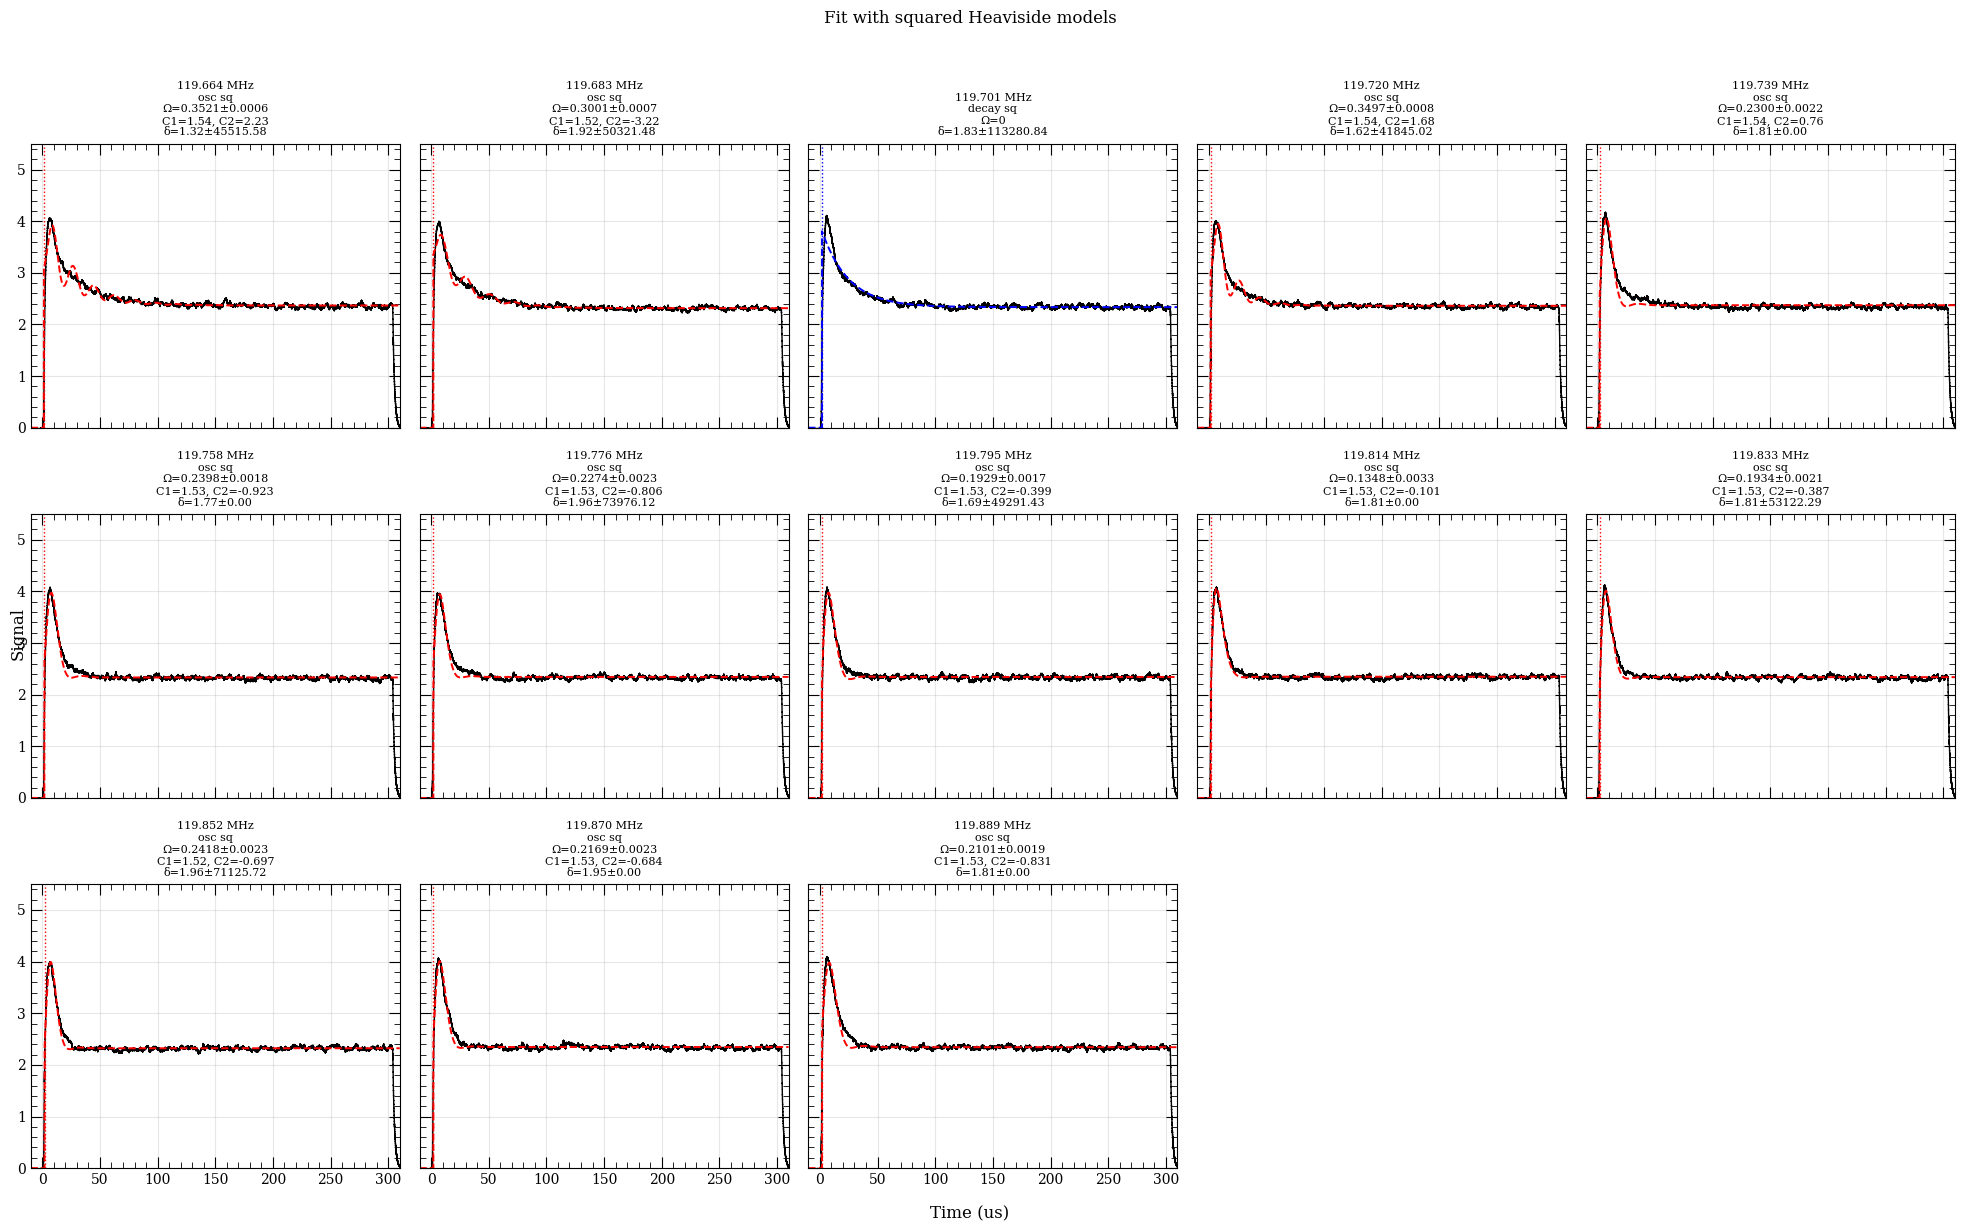

In [308]:
def plot_fit_grid_sq(
    t_us,
    averaged_traces,
    fit_results_sq,
    labels,
    ncurves,
    ncols=5,
    xlim=(-10, 310),
    ylim=(0, 5.5),
    figsize=(20, 12)
):
    nrows = int(np.ceil(ncurves / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        sharex=True,
        sharey=True
    )
    axes = np.ravel(axes)

    for i, y in enumerate(averaged_traces[:ncurves]):
        ax = axes[i]
        res = fit_results_sq[i]

        ax.plot(t_us, y, color="k", lw=1.0)

        if res["success"]:
            model_used = res["model_used"]
            popt = res["popt"]
            perr = res["perr"]

            if model_used == "osc_sq":
                y_model = model_osc_sq(t_us, *popt)
                ax.plot(t_us, y_model, "--", color="r", lw=1.4)

                A, alpha, Omega, phi, C1, C2, delta = popt
                A_err, alpha_err, Omega_err, phi_err, C1_err, C2_err, delta_err = perr

                ax.axvline(delta, color="r", ls=":", lw=1)

                ax.set_title(
                    f"{labels[i]}\n"
                    f"osc sq\n"
                    f"Ω={Omega:.4f}±{Omega_err:.4f}\n"
                    f"C1={C1:.3g}, C2={C2:.3g}\n"
                    f"δ={delta:.2f}±{delta_err:.2f}",
                    fontsize=8
                )

            elif model_used == "decay_sq":
                y_model = model_decay_sq(t_us, *popt)
                ax.plot(t_us, y_model, "--", color="b", lw=1.4)

                B, beta, D, delta = popt
                B_err, beta_err, D_err, delta_err = perr

                ax.axvline(delta, color="b", ls=":", lw=1)

                ax.set_title(
                    f"{labels[i]}\n"
                    f"decay sq\n"
                    f"Ω=0\n"
                    f"δ={delta:.2f}±{delta_err:.2f}",
                    fontsize=8
                )

        else:
            ax.set_title(f"{labels[i]}\nfit failed", fontsize=8)

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(alpha=0.3)

    for j in range(ncurves, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Fit with squared Heaviside models", y=1.02)
    fig.supxlabel("Time (us)")
    fig.supylabel("Signal")

    plt.tight_layout()
    plt.show()


plot_fit_grid_sq(
    t_us,
    averaged_traces_use,
    fit_results_sq,
    labels_use,
    ncurves
)

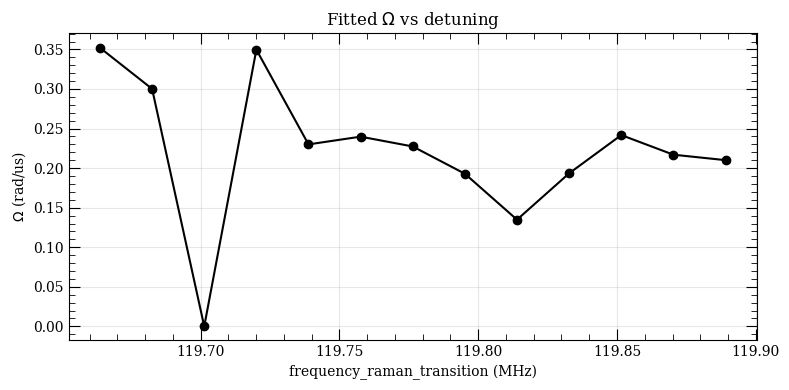

In [307]:
mask = df_sq["success"] & np.isfinite(df_sq["Omega"])

fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(
    df_sq.loc[mask, "xval"],
    df_sq.loc[mask, "Omega"],
    yerr=df_sq.loc[mask, "Omega_err"],
    fmt="o-",
    color="k",
    capsize=3
)

ax.set_xlabel(f"{xvarname} ({xvarunit})" if xvarunit else xvarname)
ax.set_ylabel(r"$\Omega$ (rad/us)")
ax.set_title(r"Fitted $\Omega$ vs detuning")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Global fit

In [ ]:
def get_trace_from_ad(ad, scope_name="PD", channel_index=0):
    return ad.scope_data[scope_name][channel_index]

def average_repeats_1d(trace, N_repeats):
    v = np.asarray(trace.v)

    n_total, n_time = v.shape
    n_groups = n_total // N_repeats

    v_trim = v[:n_groups * N_repeats]
    averaged_traces = v_trim.reshape(n_groups, N_repeats, n_time).mean(axis=1)

    return averaged_traces

def prepare_run(run_id, dataset="andor_all", scope_name="PD", channel_index=0):
    ad = atomdata(run_id, dataset)

    trace = get_trace_from_ad(ad, scope_name=scope_name, channel_index=channel_index)

    averaged_traces = average_repeats_1d(trace, ad.params.N_repeats)

    t_us = trace.t[0] * 1e6

    xvarunit, xvarmult, xvarname = detect_unit(ad, 0, xvarunit="", xvarmult=1.)

    xvals = np.array([
        ad.xvars[0][i * ad.params.N_repeats] * xvarmult
        for i in range(int(ad.xvardims[0] / ad.params.N_repeats))
    ])

    labels = [
        f"{xvals[i]:.3f} {xvarunit}"
        for i in range(len(xvals))
    ]

    ncurves = min(len(averaged_traces), len(xvals))

    return {
        "ad": ad,
        "trace": trace,
        "averaged_traces": averaged_traces[:ncurves],
        "t_us": t_us,
        "xvals": xvals[:ncurves],
        "labels": labels[:ncurves],
        "xvarunit": xvarunit,
        "xvarmult": xvarmult,
        "xvarname": xvarname,
        "ncurves": ncurves,
    }

def analyze_run(
    run,
    decimate_fit=20,
    error_threshold=0.004,
    verbose=True
):
    t_us = run["t_us"]
    averaged_traces = run["averaged_traces"]
    xvals = run["xvals"]
    labels = run["labels"]

    fit_results = []
    rows = []

    for i, y in enumerate(averaged_traces):
        if verbose:
            print(f"[{i+1}/{len(averaged_traces)}] fitting {labels[i]} ...", flush=True)

        try:
            fit_result, row, msg = fit_one_trace_sq_auto(
                t_us=t_us,
                y=y,
                label=labels[i],
                xval=xvals[i],
                index=i,
                decimate_fit=decimate_fit,
                error_threshold=error_threshold
            )

            fit_results.append(fit_result)
            rows.append(row)

            if verbose:
                print(f"    {msg}", flush=True)

        except Exception as e:
            fit_results.append({
                "success": False,
                "model_used": None,
                "popt": None,
                "pcov": None,
                "perr": None,
                "error": str(e)
            })

            rows.append(
                failed_sq_row(
                    index=i,
                    label=labels[i],
                    xval=xvals[i],
                    error=str(e)
                )
            )

            if verbose:
                print(f"    FAILED: {e}", flush=True)

    df = pd.DataFrame(rows)

    run["fit_df"] = df
    run["fit_results"] = fit_results
    run["Omega_list"] = df["Omega"].to_numpy()

    return run


In [73]:
print(np.concatenate([np.arange(64999, 65028, 1), [65029]]))

[64999 65000 65001 65002 65003 65004 65005 65006 65007 65008 65009 65010
 65011 65012 65013 65014 65015 65016 65017 65018 65019 65020 65021 65022
 65023 65024 65025 65026 65027 65029]


In [242]:
run_ids = np.concatenate([np.arange(64999, 65028, 2), [65029]])
# run_ids = np.arange(65030, 65079, 1)
all_runs = {}


for run_id in run_ids:
    try:
        print(f"\n=== Run {run_id} ===")

        run = prepare_run(run_id)
        run = analyze_run(run)

        all_runs[run_id] = run

        print("done")

    except Exception as e:
        print(f"Run {run_id} failed: {e}")


=== Run 64999 ===
64999
[atomdata timing] load total=6.669s | get_data_file(initial)=3.690s | h5_open=0.011s | headers=0.025s | core_arrays=0.451s | datavault=0.001s | scope_data=2.489s
No ROI saved in run 64999 (cached).
ROI specified by string. Referencing roi.xslx spreadsheet (PotassiumData)...
ROI andor_all found.
[atomdata timing] init total=12.473s | load_data=6.669s | setup+roi=0.002s | unshuffle_old=0.000s | initial_analysis=5.802s
[1/13] fitting 119.416 MHz ...
    osc_sq OK | Omega=0.3122, mse_rel=0.003904, Omega_err/Omega=0.001209
[2/13] fitting 119.434 MHz ...
    decay_sq OK | Omega set to 0 | mse_rel=0.004714
[3/13] fitting 119.453 MHz ...
    decay_sq OK | Omega set to 0 | mse_rel=0.005533
[4/13] fitting 119.472 MHz ...
    osc_sq OK | Omega=0.4919, mse_rel=0.002422, Omega_err/Omega=0.0006557
[5/13] fitting 119.491 MHz ...
    osc_sq OK | Omega=0.4607, mse_rel=0.001753, Omega_err/Omega=0.0006078
[6/13] fitting 119.510 MHz ...
    osc_sq OK | Omega=0.3968, mse_rel=0.0015

C:\Users\jarjarbinks\code\wax\waxa-src\waxa\fitting\gaussian.py:102: RuntimeWarning: invalid value encountered in divide
  ynorm = ynorm/(np.max(ynorm) - np.min(ynorm))


[atomdata timing] init total=12.693s | load_data=6.065s | setup+roi=0.002s | unshuffle_old=0.000s | initial_analysis=6.626s
[1/13] fitting 119.605 MHz ...
    osc_sq OK | Omega=0.3921, mse_rel=0.001955, Omega_err/Omega=0.001598
[2/13] fitting 119.623 MHz ...
    osc_sq OK | Omega=0.4730, mse_rel=0.002083, Omega_err/Omega=0.001618
[3/13] fitting 119.642 MHz ...
    osc_sq OK | Omega=0.3791, mse_rel=0.001298, Omega_err/Omega=0.0022
[4/13] fitting 119.661 MHz ...
    osc_sq OK | Omega=0.2563, mse_rel=0.000958, Omega_err/Omega=0.008003
[5/13] fitting 119.680 MHz ...
    osc_sq OK | Omega=0.2916, mse_rel=0.001036, Omega_err/Omega=0.005881
[6/13] fitting 119.699 MHz ...
    osc_sq OK | Omega=0.2988, mse_rel=0.0008392, Omega_err/Omega=0.004764
[7/13] fitting 119.717 MHz ...
    osc_sq OK | Omega=0.2842, mse_rel=0.0008905, Omega_err/Omega=0.005358
[8/13] fitting 119.736 MHz ...
    osc_sq OK | Omega=0.2993, mse_rel=0.0008783, Omega_err/Omega=0.005226
[9/13] fitting 119.755 MHz ...
    osc_sq O

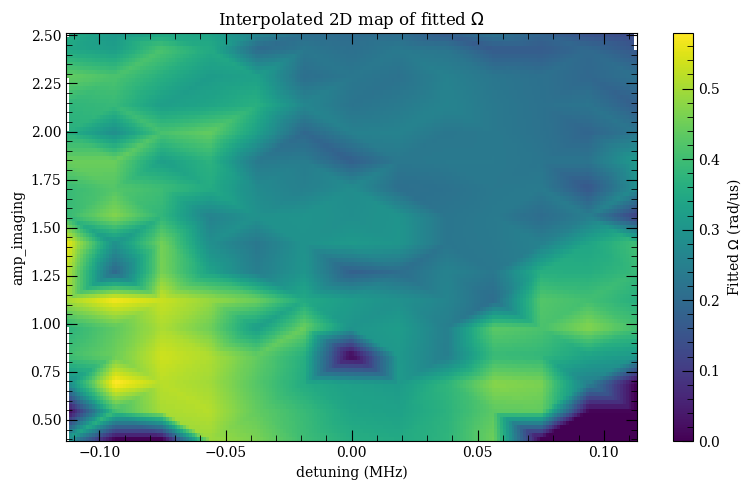

In [245]:
from scipy.interpolate import griddata
all_rows = []

for run_id, run in all_runs.items():
    df = run["fit_df"]
    ad = run["ad"]

    amp_imaging = ad.params.amp_imaging

    for _, row in df.iterrows():
        all_rows.append({
            "run_id": run_id,
            "xval": row["xval"]-np.mean(df["xval"]),
            "omega": row["Omega"],
            "omega_err": row["Omega_err"],
            "success": row["success"],
            "amp_imaging": amp_imaging
        })
df_all = pd.DataFrame(all_rows)

df_plot = df_all[
    df_all["success"]
    & np.isfinite(df_all["omega"])
    & np.isfinite(df_all["xval"])
    & np.isfinite(df_all["amp_imaging"])
].copy()

x = df_plot["xval"].values
y = df_plot["amp_imaging"].values
z = df_plot["omega"].values

# for i in range(len(z)):
#     if z[i] <= 0.055:
#         z[i] = 0
#     else :
#         z[i] = np.sqrt(np.linalg.norm(z[i]**2 -  x[i]**2))

xi = np.linspace(np.min(x), np.max(x), 200)
yi = np.linspace(np.min(y), np.max(y), 100)

X, Y = np.meshgrid(xi, yi)


Z = griddata(
    points=(x, y),
    values=z,
    xi=(X, Y),
    method="linear"
)

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.pcolormesh(
    X,
    Y,
    Z,
    shading="auto",
    cmap="viridis"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"Fitted $\Omega$ (rad/us)")

ax.set_xlabel("detuning (MHz)")
ax.set_ylabel("amp_imaging")
ax.set_title(r"Interpolated 2D map of fitted $\Omega$")

plt.tight_layout()
plt.show()